In [1]:
from ase.io.trajectory import Trajectory, TrajectoryWriter

In [2]:
writer = TrajectoryWriter("combined_NVT-330K-ZnO.traj", mode="w")

In [3]:
for fname in ["./filtered_NVT-330K-ZnO_5NaCl.traj", "./filtered_NVT-330K-ZnO_1ZnCl2_5NaCl.traj"]:
    for atoms in Trajectory(fname):
        writer.write(atoms)

writer.close()

In [5]:
from ase.io.trajectory import Trajectory
traj = Trajectory("combined_NVT-330K-ZnO.traj")
print("Total frames:", len(traj))

Total frames: 5854


In [6]:
from pinn.io import load_ase

dataset1 = load_ase("./filtered_NVT-330K-ZnO_5NaCl.traj", splits=None, shuffle=False)
dataset2 = load_ase("./filtered_NVT-330K-ZnO_1ZnCl2_5NaCl.traj", splits=None, shuffle=False)
# dataset3 = load_ase("./combined_NVT-330K-ZnO_aqNaCl_ZnCl2.traj", splits=None, shuffle=False)

2026-08-17 08:48:32.168922: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-17 08:49:11.030628: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [7]:
def dataset_to_dict(dataset):
    data_dict = {}
    import numpy as np
    for element in dataset.as_numpy_iterator():
        for key, value in element.items():
            if key not in data_dict:
                data_dict[key] = []
            data_dict[key].append(value)

    # convert lists to arrays
    for key in data_dict:
        data_dict[key] = np.array(data_dict[key])

    # print shapes
    for key, value in data_dict.items():
        print(f"Key: {key}, Value: {value.shape}")

    return data_dict

In [8]:
# put datasets in a list
datasets = [dataset1, dataset2] # dataset 3 has variable size atoms!
data_dicts = {}

In [9]:
for i,ds in enumerate(datasets, start=1):
    data_dicts[f"data_dict_{i}"] = dataset_to_dict(ds)

Key: elems, Value: (2654, 607)
Key: coord, Value: (2654, 607, 3)
Key: cell, Value: (2654, 3, 3)
Key: e_data, Value: (2654,)
Key: f_data, Value: (2654, 607, 3)
Key: elems, Value: (3200, 610)
Key: coord, Value: (3200, 610, 3)
Key: cell, Value: (3200, 3, 3)
Key: e_data, Value: (3200,)
Key: f_data, Value: (3200, 610, 3)


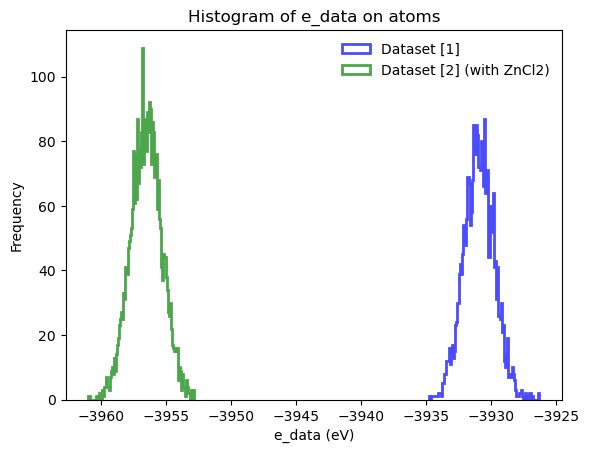

In [12]:
import matplotlib.pyplot as plt
# Label the datasets
labels = ['Dataset [1]', 'Dataset [2] (with ZnCl2)']
colors = ['blue', 'green']

# Loop through each dataset dictionary
for i, (key, data_dict) in enumerate(data_dicts.items()):
    plt.hist(data_dict['e_data'], bins=100, alpha=0.7, 
             label=labels[i], color=colors[i], histtype='step',linewidth=2)


# plt.hist(data_dicts['data_dict_4']['e_data'], bins=500, alpha=0.7, 
            #  label='Dataset 3', color='orange', histtype='step',linewidth=2)
plt.xlabel('e_data (eV)')
plt.ylabel('Frequency')
plt.title('Histogram of e_data on atoms')
plt.legend(frameon=False)
plt.show()

In [13]:
from pinn.io import load_ase, write_tfrecord


dataset = load_ase("./combined_NVT-330K-ZnO.traj", splits=None, shuffle=True)

In [14]:
write_tfrecord('./ZnO_aqNaCl_ZnCl2-330K-macer2scan-5854.yml', dataset)

 5854 samples written to ./ZnO_aqNaCl_ZnCl2-330K-macer2scan-5854.tfr, done.
